# 🌾 PIPELINE INSTANCE SEGMENTATION - BỆNH LÁ LÚA (KAGGLE)
**Mô hình:** YOLOv26m &nbsp;|&nbsp; **Phần cứng yêu cầu:** Kaggle GPU (Tesla T4 x2 hoặc x1)  
**Mục tiêu:** Cung cấp quy trình huấn luyện end-to-end cho mô hình phát hiện và khoanh vùng vết bệnh trên lá lúa.

---
### 📖 HƯỚNG DẪN CÁCH CHẠY DÀNH CHO TEAM:
1. **Bật GPU trên Kaggle:** Ở panel bên phải -> `Session options` -> `Accelerator` -> Chọn `GPU T4 x2` hoặc `P100`. (Bật Internet = ON).
2. **Thêm dữ liệu (Add Data):** Nhấn nút `Add Input` (Góc trên phải) để đưa dataset ảnh lúa đã tiền xử lý vào notebook.
3. **Tùy biến Cấu hình:** Tất cả tham số (Epochs, Batch size, Lr...) đều nằm chung trong **CELL 1**. Bạn chỉ cần thay đổi giá trị ở đó.
4. **Trình tự chạy:**
   - **Train một mô hình mới:** Chạy tuần tự **BƯỚC 1 ➡️ BƯỚC 2A ➡️ BƯỚC 3 ➡️ BƯỚC 4**.
   - **Train tiếp (Resume):** Chạy tuần tự **BƯỚC 1 ➡️ BƯỚC 2B ➡️ BƯỚC ...**

---
## BƯỚC 1: IMPORT THƯ VIỆN & CẤU HÌNH TẬP TRUNG (CONFIG)
> ⚠️ **Hành động của Team:** Chỉ cần điền và chỉnh sửa các thống số trong Lớp `PipelineConfig` ở Cell code ngay bên dưới.
> - Tránh sửa can thiệp vào các hàm bên dưới để đảm bảo tính ổn định của hệ thống.
> - **Lưu ý:** Biến `BASE_INPUT_DIR` phải trỏ đúng vào thư mục dataset (được sinh ra sau khi bạn ấn Add Data).

In [1]:
# ============================================================
# 1.1 — CÀI ĐẶT THƯ VIỆN (chạy 1 lần duy nhất trên Kaggle)
# ============================================================
# ⚠️ Pin Pillow < 11.2 để tránh lỗi PIL._typing._Ink
!pip install "Pillow==10.4.0", sahi -q
# Cài ultralytics và các thư viện phụ trợ (KHÔNG dùng -U để tránh nâng Pillow)
!pip install ultralytics requests opencv-python matplotlib -q


# ============================================================
# 1.2 — IMPORT THƯ VIỆN
# ============================================================
import os
import time
import yaml
import shutil
import requests
import torch                        # Kiểm tra CUDA / VRAM
import cv2
import ultralytics
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from pathlib import Path
from dataclasses import dataclass, field
from typing import List
from PIL import Image
from ultralytics import YOLO
from io import BytesIO
from PIL import Image
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import read_image

# ============================================================
# 1.3 — CẤU HÌNH TẬP TRUNG (CONFIG / CONSTANTS)
# ============================================================
# Team chỉ cần thay đổi giá trị ở đây, logic bên dưới tự nhận.
# Dùng frozen dataclass để tránh vô tình ghi đè config giữa chừng.

@dataclass(frozen=True)
class PipelineConfig:
    """Tập trung toàn bộ siêu tham số & đường dẫn cho pipeline."""

    # ---------- ĐƯỜNG DẪN ----------
    BASE_INPUT_DIR: str = '/kaggle/input/datasets/ptquanh/preprocessed-dataset-v2/kaggle/working/PTIT_RICE_SEGMENTATION'       # Thư mục gốc chứa dataset Kaggle
    WORKING_DIR: str = '/kaggle/working'         # Thư mục làm việc (output)
    PROJECT_DIR: str = '/kaggle/working/OptimizedModel_CopyPasteAugmentationDataset_16042026'  # Lưu kết quả training
    RUN_NAME: str = 'yolo26m_seg_train'          # Tên run (tạo subfolder)

    # ---------- MÔ HÌNH ----------
    # Nếu 'yolo26m-seg' là file trọng số custom (.pt) đặt trên Kaggle:
    #   → đặt đường dẫn đầy đủ, ví dụ '/kaggle/input/weights/yolo26m-seg.pt'
    # Nếu là mã biến thể Ultralytics (vd: yolo11m-seg, yolo8m-seg):
    #   → ghi tên chuẩn Ultralytics, thư viện tự download.
    MODEL_WEIGHTS: str = 'yolo26m-seg.pt'

    # ---------- SIÊU THAM SỐ HUẤN LUYỆN ----------
    EPOCHS: int = 120                # Số epoch tối đa
    PATIENCE: int = 20               # Early Stopping: dừng nếu mAP không cải thiện sau N epoch
    BATCH_SIZE: int = 8             # Batch size an toàn cho T4-16GB ở imgsz=768
    IMAGE_SIZE: int = 1024            # Kích thước ảnh train (768 giữ chi tiết vết bệnh nhỏ)
    WORKERS: int = 4                 # Số luồng DataLoader (Kaggle có 4 CPU cores)
    DEVICE: str = '0,1'                  # GPU index (0 = GPU đầu tiên)
    
    OPTIMIZER: str = 'AdamW'         # Thuật toán tối ưu
    LR0: float = 0.001              # Learning rate khởi đầu
    LRF: float = 0.01               # Learning rate cuối (tỷ lệ so với lr0)
    WEIGHT_DECAY: float = 0.0005     # L2 Regularization
    WARMUP_EPOCHS: int = 5           # Số epoch khởi động (warm-up)
    COS_LR: bool = True             # Sử dụng Cosine Annealing LR Scheduler
    AMP: bool = True                # Mixed Precision (FP16) — tiết kiệm ~30% VRAM

    # ---------- DATA AUGMENTATION (tối ưu cho ảnh thực vật) ----------
    MOSAIC: float = 1.0             # Trộn 4 ảnh → chống center-bias
    CLOSE_MOSAIC: int = 15          # Tắt mosaic N epoch cuối → ổn định hội tụ
    MIXUP: float = 0.0             # Trộn 2 ảnh mờ → tăng tính tổng quát
    COPY_PASTE: float = 0.0         # Copy-paste object → tăng recall cho vết bệnh nhỏ
    DEGREES: float = 15.0           # Xoay ngẫu nhiên (lá lúa có nhiều hướng)
    TRANSLATE: float = 0.1          # Dịch chuyển ảnh 10%
    SCALE: float = 0.5              # Phóng/thu ± 50%
    SHEAR: float = 2.0              # Biến dạng nhẹ
    FLIPUD: float = 0.5             # Lật dọc 50% (lá có thể úp/ngửa)
    FLIPLR: float = 0.5             # Lật ngang 50%
    HSV_H: float = 0.02            # Biến đổi Hue ± 2% (nhạy với màu lá)
    HSV_S: float = 0.4             # Biến đổi Saturation ± 70% (mô phỏng ánh sáng)
    HSV_V: float = 0.3             # Biến đổi Value ± 40% (mô phỏng bóng râm)
    ERASING: float = 0.0           # Random Erasing → chống overfitting vùng cụ thể
    CLS: float = 1.5
    
    # ---------- INFERENCE ----------
    CONF_THRESH: float = 0.25       # Ngưỡng confidence cho prediction
    IOU_THRESH: float = 0.45        # Ngưỡng IoU cho NMS
    INFER_IMG_SIZE: int = 1024      # Kích thước ảnh inference (to hơn → chi tiết hơn)
    AGNOSTIC_NMS: bool = True       # NMS bỏ qua class → tránh box đè nhau

    # ---------- DATASET ----------
    NUM_CLASSES: int = 7
    CLASS_NAMES: tuple = (
        'Bacterial blight',         # Bạc lá
        'Brown spot',               # Đốm nâu
        'Grain discoloration',      # Biến màu hạt
        'Leaf blast',               # Đạo ôn lá
        'Leaf scald',               # Cháy lá
        'Narrow brown',             # Đốm sọc nâu
        'Pesticide residue',        # Dư lượng thuốc
    )

    # ---------- URL ẢNH THỰC TẾ (PRACTICAL) ----------
    # URL ảnh ngoài thực tế — KHÔNG nằm trong tập train/valid/test
    # Dùng để kiểm chứng model trên dữ liệu "chưa bao giờ thấy" (practical)
    SAMPLE_PRACTICAL_URL: str = (
        '/kaggle/input/datasets/ptquanh/pratical-set/bac_la_1.jpg'
    )

    # ---------- PROPERTY TIỆN ÍCH ----------
    @property
    def yaml_path(self) -> str:
        """Đường dẫn file data.yaml được sinh ra."""
        return os.path.join(self.WORKING_DIR, 'data.yaml')

    @property
    def best_weights_path(self) -> str:
        """Đường dẫn tới file best.pt sau khi train xong."""
        return os.path.join(self.PROJECT_DIR, self.RUN_NAME, 'weights', 'best.pt')

    @property
    def last_weights_path(self) -> str:
        """Đường dẫn tới file last.pt (checkpoint cuối cùng)."""
        return os.path.join(self.PROJECT_DIR, self.RUN_NAME, 'weights', 'last.pt')


# Khởi tạo config duy nhất cho toàn bộ pipeline
CFG = PipelineConfig()

# ============================================================
# 1.4 — KIỂM TRA MÔI TRƯỜNG (ĐÃ FIX LỖI MULTI-GPU)
# ============================================================
print('=' * 60)
print('⚙️  KIỂM TRA CẤU HÌNH HỆ THỐNG')
print('=' * 60)
ultralytics.checks()  # In thông tin GPU, CUDA, thư viện

if torch.cuda.is_available():
    # Xử lý chuỗi '0,1' thành số 0 để hàm PyTorch đọc được
    first_device = str(CFG.DEVICE).split(',')[0].strip()
    device_id = int(first_device) if first_device.isdigit() else 0
    
    gpu_name = torch.cuda.get_device_name(device_id)
    vram_gb = torch.cuda.get_device_properties(device_id).total_memory / (1024**3)
    
    # Nếu dùng multi-gpu thì nhân đôi hiển thị VRAM cho chuẩn
    num_gpus = len(str(CFG.DEVICE).split(',')) if isinstance(CFG.DEVICE, str) else 1
    total_vram = vram_gb * num_gpus
    
    print(f'🖥️  GPU: {num_gpus}x {gpu_name} | Tổng VRAM: {total_vram:.1f} GB')
    print(f'🔧  AMP (FP16): {"BẬT" if CFG.AMP else "TẮT"}')
    print(f'📐  Image size: {CFG.IMAGE_SIZE} | Batch: {CFG.BATCH_SIZE}')
else:
    print('⚠️  KHÔNG PHÁT HIỆN GPU – training sẽ rất chậm!')

print(f'📁  Model weights: {CFG.MODEL_WEIGHTS}')
print('=' * 60)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.2/8062.4 GB disk)
🖥️  GPU: 2x Tesla T4 | Tổng VRAM: 29.1 GB
🔧  AMP (FP16): BẬT
📐  Image size: 1024 | Batch: 8
📁  Model weights: yolo26m-seg.pt


---
## BƯỚC 2A: CHUẨN BỊ DỮ LIỆU & HUẤN LUYỆN (TRAINING TỪ ĐẦU)
> 🚀 **Hành động của Team:** Chạy Cell này nếu bạn **bắt đầu huấn luyện một mô hình mới**.
> - Đoạn mã sẽ tự động quét thư mục `train` và `valid`, tạo file cấu hình `data.yaml` cho YOLO và bắt đầu vòng lặp Train.
> - Tiến trình sẽ in liên tục bên dưới để bạn theo dõi. (Quá trình này tốn từ vài chục phút tới vài giờ).

In [3]:
# ============================================================
# 2.1 — TÌM KIẾM DATASET TỰ ĐỘNG
# ============================================================
def find_dataset(base_dir: str) -> str:
    print('\n🔍 Đang quét tìm dataset...')
    for root, dirs, _ in os.walk(base_dir):
        if 'train' in dirs and 'valid' in dirs:
            train_images = os.path.join(root, 'train', 'images')
            if os.path.isdir(train_images):
                print(f'✅ Dataset tìm thấy tại: {root}')
                return root
    raise FileNotFoundError(
        '❌ Không tìm thấy thư mục dataset hợp lệ (cần train/images & valid/images).\n'
        f'   Đã quét trong: {base_dir}'
    )

# ============================================================
# 2.2 — TẠO FILE data.yaml CHO ULTRALYTICS
# ============================================================
def create_data_yaml(dataset_path: str, cfg) -> str:
    data_config = {
        'train': os.path.join(dataset_path, 'train', 'images'),
        'val': os.path.join(dataset_path, 'valid', 'images'),
        'nc': cfg.NUM_CLASSES,
        'names': list(cfg.CLASS_NAMES),
    }

    test_images = os.path.join(dataset_path, 'test', 'images')
    if os.path.isdir(test_images):
        data_config['test'] = test_images
        print(f'📂 Tìm thấy tập TEST: {test_images}')
    else:
        print('ℹ️  Không tìm thấy thư mục test/images — bỏ qua tập test')

    os.makedirs(cfg.WORKING_DIR, exist_ok=True)
    with open(cfg.yaml_path, 'w', encoding='utf-8') as f:
        yaml.dump(data_config, f, sort_keys=False, allow_unicode=True)

    print(f'✅ Đã tạo data.yaml tại: {cfg.yaml_path}')
    return cfg.yaml_path

# ============================================================
# 2.3 — KHỞI TẠO MÔ HÌNH
# ============================================================
def build_model(cfg) -> YOLO:
    weight_path = cfg.MODEL_WEIGHTS
    if os.path.isabs(weight_path) and not os.path.exists(weight_path):
        raise FileNotFoundError(f'❌ Không tìm thấy file trọng số: {weight_path}')

    print(f'\n🚀 Đang load mô hình: {weight_path}')
    model = YOLO(weight_path)
    print(f'✅ Mô hình đã sẵn sàng — Architecture: {model.model.__class__.__name__}')
    return model

# ============================================================
# 2.4 — HÀM HUẤN LUYỆN CHÍNH (ĐÃ FIX CUDA ERROR)
# ============================================================
def run_training(model: YOLO, yaml_path: str, cfg):
    print('\n' + '=' * 60)
    print('⏳ BẮT ĐẦU HUẤN LUYỆN')
    print(f'   Epochs: {cfg.EPOCHS} | Batch : {cfg.BATCH_SIZE} | ImgSz: {cfg.IMAGE_SIZE}')
    print('=' * 60)

    # ĐẢM BẢO VRAM TRỐNG TRƯỚC KHI TRAIN ĐỂ TRÁNH LỖI "CUDA UNKNOWN ERROR"
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("🧹 Đã dọn dẹp cache GPU (VRAM).")

    start_time = time.time()

    results = model.train(
        data=yaml_path,
        epochs=cfg.EPOCHS,
        imgsz=cfg.IMAGE_SIZE,
        batch=cfg.BATCH_SIZE,

        workers=cfg.WORKERS,          
        device=cfg.DEVICE,            
        amp=cfg.AMP,

        patience=cfg.PATIENCE,        
        weight_decay=cfg.WEIGHT_DECAY,  
        optimizer=cfg.OPTIMIZER,
        lr0=cfg.LR0,                  
        lrf=cfg.LRF,                  
        warmup_epochs=cfg.WARMUP_EPOCHS,  
        cos_lr=cfg.COS_LR,            
        cls=cfg.CLS,
        
        mosaic=cfg.MOSAIC,            
        close_mosaic=cfg.CLOSE_MOSAIC,  
        mixup=cfg.MIXUP,              
        copy_paste=cfg.COPY_PASTE,    
        degrees=cfg.DEGREES,          
        translate=cfg.TRANSLATE,      
        scale=cfg.SCALE,              
        shear=cfg.SHEAR,              
        flipud=cfg.FLIPUD,            
        fliplr=cfg.FLIPLR,            
        hsv_h=cfg.HSV_H,             
        hsv_s=cfg.HSV_S,             
        hsv_v=cfg.HSV_V,             
        erasing=cfg.ERASING,         

        project=cfg.PROJECT_DIR,
        name=cfg.RUN_NAME,
        exist_ok=True,               
        save=True,                   
        save_period=10,              
        plots=True,                  
        verbose=True,
    )

    elapsed = time.time() - start_time
    hours, remainder = divmod(elapsed, 3600)
    minutes, seconds = divmod(remainder, 60)

    print('\n' + '=' * 60)
    print(f'✅ HOÀN TẤT HUẤN LUYỆN trong {int(hours)}h {int(minutes)}m {int(seconds)}s')
    print(f'📂 Kết quả lưu tại: {cfg.PROJECT_DIR}/{cfg.RUN_NAME}')
    print('=' * 60)

    return results

# ============================================================
# 2.5 — CHẠY PIPELINE SETUP + TRAIN
# ============================================================
dataset_path = find_dataset(CFG.BASE_INPUT_DIR)
yaml_config_path = create_data_yaml(dataset_path, CFG)
model = build_model(CFG)
train_results = run_training(model, yaml_config_path, CFG)


🔍 Đang quét tìm dataset...
✅ Dataset tìm thấy tại: /kaggle/input/datasets/ptquanh/preprocessed-dataset-v2/kaggle/working/PTIT_RICE_SEGMENTATION
📂 Tìm thấy tập TEST: /kaggle/input/datasets/ptquanh/preprocessed-dataset-v2/kaggle/working/PTIT_RICE_SEGMENTATION/test/images
✅ Đã tạo data.yaml tại: /kaggle/working/data.yaml

🚀 Đang load mô hình: yolo26m-seg.pt
✅ Mô hình đã sẵn sàng — Architecture: SegmentationModel

⏳ BẮT ĐẦU HUẤN LUYỆN
   Epochs: 120 | Batch : 8 | ImgSz: 1024
🧹 Đã dọn dẹp cache GPU (VRAM).
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degre

W0416 10:32:36.090000 154 torch/distributed/elastic/agent/server/api.py:739] Received 2 death signal, shutting down workers
W0416 10:32:36.100000 154 torch/distributed/elastic/multiprocessing/api.py:1010] Sending process 157 closing signal SIGINT
W0416 10:32:36.105000 154 torch/distributed/elastic/multiprocessing/api.py:1010] Sending process 158 closing signal SIGINT
[rank1]: Traceback (most recent call last):
[rank1]:   File "/root/.config/Ultralytics/DDP/_temp_5c1ryxao139846617431840.py", line 19, in <module>
[rank1]:     results = trainer.train()
[rank1]:               ^^^^^^^^^^^^^^^
[rank1]:   File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/trainer.py", line 246, in train
[rank1]:     self._do_train()
[rank1]:   File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/trainer.py", line 439, in _do_train
[rank1]:     loss, self.loss_items = self.model(batch)
[rank1]:                             ^^^^^^^^^^^^^^^^^
[rank1]:   File "/usr/local/lib/python3.12/di

KeyboardInterrupt: 

In [ ]:
!rm -f /kaggle/working/practical_result_1775664007.jpg

---
## BƯỚC 2B: TIẾP TỤC HUẤN LUYỆN TỪ CHECKPOINT CŨ (RESUME)
> 🚨 **CẢNH BÁO:** Nếu bạn ĐÃ CHẠY **BƯỚC 2A**, thì nhớ **KHÔNG CHẠY** cell này nữa.
> - **Mục đích:** Chỉ chạy BƯỚC 2B nếu trước đó đang học thì bị ngắt quãng (vd hết giờ, rớt mạng Kaggle).
> - **Thao tác:** Đưa checkpoint cũ (VD: file `last.pt`) vào Kaggle thông qua Add Data và cập nhật đường dẫn `checkpoint_path` bên dưới.

In [1]:
!pip install ultralytics requests opencv-python matplotlib -q

from ultralytics import YOLO

import yaml
from ultralytics import YOLO

old_yaml_path = '/kaggle/input/datasets/ptquanh/preprocessed-dataset/PTIT_RICE_SEGMENTATION/data.yaml'
new_yaml_path = '/kaggle/working/resume_training_data.yaml'

# 1. Đọc file yaml gốc
with open(old_yaml_path, 'r') as f:
    dataset_cfg = yaml.safe_load(f)

# 2. Ghi đè lại đường dẫn thành đường dẫn tuyệt đối trỏ thẳng vào /kaggle/input
base_dir = '/kaggle/input/datasets/ptquanh/preprocessed-dataset/PTIT_RICE_SEGMENTATION'
dataset_cfg['path'] = base_dir
dataset_cfg['train'] = f'{base_dir}/train/images'
dataset_cfg['val'] = f'{base_dir}/valid/images'
dataset_cfg['test'] = f'{base_dir}/test/images'

# 3. Lưu thành file yaml mới ở /kaggle/working/
with open(new_yaml_path, 'w') as f:
    yaml.dump(dataset_cfg, f)

print(f"Đã tạo file cấu hình mới tại: {new_yaml_path}")

# 4. Resume quá trình train bằng file yaml MỚI
model = YOLO('/kaggle/working/Optimized_Model_14042026/yolo26m_seg_train/weights/last.pt')
results = model.train(resume=True, data=new_yaml_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.2 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Đã tạo file cấu hình mới tại: /kaggle/working/custom_data.yaml
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/custom_data.yaml, degrees=15.0, deterministic=True, device=0,1, dfl=

---
## BƯỚC 3: ĐÁNH GIÁ (TEST) VÀ DỰ ĐOÁN THỬ (INFERENCE)
> 📊 **Hành động của Team:** Sau khi hệ thống Train xong hoặc resume thành công, chạy Cell này để:
> 1. Gọi hàm tính độ chính xác trung bình (mAP) nghiêm ngặt trên tập **test** (dữ liệu mô hình hoàn toàn chưa nhìn thấy).
> 2. Gọi hàm dự đoán trên **1 tấm hình thực tế** để kiểm tra thị giác kết quả khoanh vùng (bounding box + mask).


🔬 INFERENCE TRÊN ẢNH THỰC TẾ (CUSTOM THRESHOLD)
----------------------------------------
✅ Đã load model từ: /kaggle/working/OptimizedModel_CopyPasteAugmentationDataset_16042026/yolo26m_seg_train/weights/best.pt
📐 Ảnh input: 1480×279
🔄 Đang chạy suy luận với base_conf=0.15 ...
📊 Phát hiện 7 vùng bệnh sau khi lọc threshold
  [1] Brown spot: 39.98% 
  [2] Brown spot: 39.47% 
  [3] Brown spot: 26.32% 
  [4] Brown spot: 25.92% 
  [5] Brown spot: 21.45% (*)
  [6] Brown spot: 21.21% (*)
  [7] Brown spot: 16.16% (*)


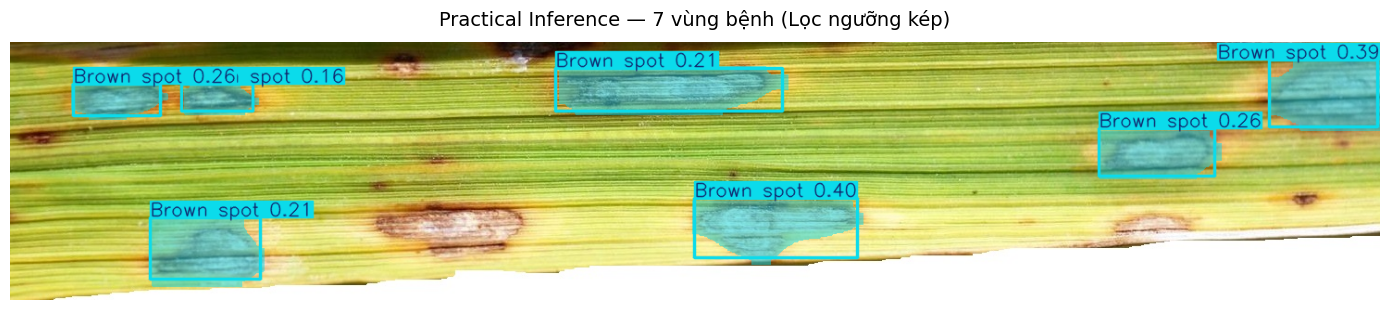

💾 Ảnh kết quả đã lưu: /kaggle/working/practical_result_dual_thresh_1776336098.jpg

🔪 INFERENCE BẰNG SAHI (SLICING AIDED HYPER INFERENCE)
-------------------------------------------------------
🔄 Đang nạp model vào SAHI (Device: cuda:0)...
🧩 Đang cắt ảnh và suy luận (Slice size: 320x320, Overlap: 20%)...
Performing prediction on 6 slices.
📊 Phát hiện 9 vùng bệnh sau khi gộp và lọc threshold.
  [1] Brown spot: 39.98% 
  [2] Brown spot: 39.47% 
  [3] Brown spot: 36.81% 
  [4] Brown spot: 26.32% 
  [5] Brown spot: 25.97% 
  [6] Brown spot: 25.92% 
  [7] Brown spot: 22.51% (*)
  [8] Brown spot: 21.39% (*)
  [9] Brown spot: 21.21% (*)


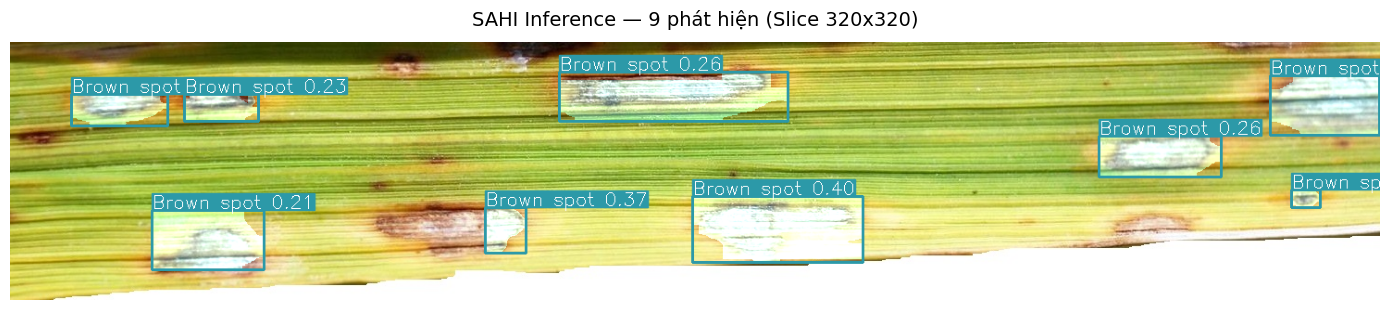

💾 Đã lưu kết quả tại: /kaggle/working/sahi_outputs/sahi_eval_1776336102.png


In [7]:
# ============================================================
# 3.1 — HÀM ĐÁNH GIÁ TRÊN TẬP TEST
# ============================================================
def evaluate_on_test(weights_path: str, test_dir: str, cfg: PipelineConfig) -> None:
    """
    Đánh giá (validate) mô hình trên tập TEST bằng cách truyền thẳng path.
    Hàm sẽ tự động tạo một file data.yaml tạm thời để map đường dẫn mới.
    """
    print('\n' + '=' * 60)
    print('📊 ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST')
    print('   (Dữ liệu mô hình chưa bao giờ thấy trong training)')
    print('=' * 60)

    # 1. Kiểm tra file weights tồn tại
    if not os.path.exists(weights_path):
        print(f'⚠️ Không tìm thấy weights: {weights_path}')
        return
        
    # 2. Kiểm tra folder test tồn tại
    if not os.path.exists(test_dir):
        print(f'⚠️ Không tìm thấy folder test: {test_dir}')
        return

    # 3. TẠO FILE YAML TẠM THỜI (Khắc phục lỗi FileNotFoundError)
    # Gán train, val, test đều trỏ về test_dir để tránh YOLO báo lỗi thiếu key
    temp_yaml_data = {
        'train': test_dir,
        'val': test_dir, 
        'test': test_dir,
        'nc': len(cfg.CLASS_NAMES),
        'names': list(cfg.CLASS_NAMES)
    }
    
    temp_yaml_path = os.path.join(cfg.WORKING_DIR, 'temp_test_data.yaml')
    with open(temp_yaml_path, 'w', encoding='utf-8') as f:
        yaml.dump(temp_yaml_data, f, default_flow_style=False, sort_keys=False)
        
    print(f'⚙️ Đã tạo cấu hình YAML tạm thời tại: {temp_yaml_path}')

    # 4. Load mô hình tốt nhất
    best_model = YOLO(weights_path)
    print(f'✅ Đã load model từ: {weights_path}')

    # 5. Chạy validation và ép dùng file yaml tạm thời
    print('\n🔄 Đang chấm điểm trên tập test...')
    metrics = best_model.val(
        data=temp_yaml_path,         # Ép dùng YAML tạm thời, bỏ qua YAML lưu trong best.pt
        split='test',                # Chỉ định dùng key 'test'
        imgsz=cfg.IMAGE_SIZE,        
        batch=cfg.BATCH_SIZE,
        device=cfg.DEVICE,
        verbose=True,
    )

    # ---- In kết quả Segmentation metrics ----
    print('\n' + '-' * 50)
    print('🏆 KẾT QUẢ ĐÁNH GIÁ (Segmentation Masks)')
    print('-' * 50)
    print(f'  mAP50          : {metrics.seg.map50:.4f}')
    print(f'  mAP50-95       : {metrics.seg.map:.4f}')

    # In Precision / Recall trung bình
    if hasattr(metrics.seg, 'mp') and hasattr(metrics.seg, 'mr'):
        print(f'  Precision (TB) : {metrics.seg.mp:.4f}')
        print(f'  Recall (TB)    : {metrics.seg.mr:.4f}')

    # In mAP50 theo từng class (nếu có)
    if hasattr(metrics.seg, 'maps') and metrics.seg.maps is not None:
        print('\n  Chi tiết mAP50-95 theo class:')
        for i, class_map in enumerate(metrics.seg.maps):
            class_name = cfg.CLASS_NAMES[i] if i < len(cfg.CLASS_NAMES) else f'Class {i}'
            print(f'    {class_name:.<30s} {class_map:.4f}')

    print('-' * 50)
    print('✅ Đánh giá hoàn tất!')


# ============================================================
# 3.2 — HÀM INFERENCE THỰC TẾ - ĐÃ TỐI ƯU PER-CLASS THRESHOLD (PRACTICAL — KHÔNG CÓ NHÃN)
# ============================================================
def run_inference(
    weights_path: str,
    image_source,  
    cfg: PipelineConfig,
) -> None:
    print('\n🔬 INFERENCE TRÊN ẢNH THỰC TẾ (CUSTOM THRESHOLD)')
    print('-' * 40)

    if not os.path.exists(weights_path):
        print(f'⚠️ Không tìm thấy weights: {weights_path}')
        return

    best_model = YOLO(weights_path)
    print(f'✅ Đã load model từ: {weights_path}')

    # ---- Xử lý input ảnh ----
    if isinstance(image_source, str) and image_source.startswith('http'):
        print(f'🌐 Đang tải ảnh từ URL...')
        try:
            response = requests.get(image_source, timeout=30)
            response.raise_for_status()
            img_pil = Image.open(BytesIO(response.content)).convert('RGB')
        except Exception as e:
            print(f'❌ Lỗi khi tải ảnh: {e}')
            return
    elif isinstance(image_source, str):
        if not os.path.exists(image_source):
            print(f'❌ File không tồn tại: {image_source}')
            return
        img_pil = Image.open(image_source).convert('RGB')
    elif isinstance(image_source, Image.Image):
        img_pil = image_source.convert('RGB')
    else:
        print(f'❌ Loại input không hỗ trợ: {type(image_source)}')
        return

    print(f'📐 Ảnh input: {img_pil.size[0]}×{img_pil.size[1]}')

    # ---- BƯỚC 1: Quét toàn bộ với ngưỡng cực thấp (0.15) ----
    print('🔄 Đang chạy suy luận với base_conf=0.15 ...')
    LOW_CONF = 0.15
    preds = best_model.predict(
        source=img_pil,
        conf=LOW_CONF,                 # Ép xuống 0.15 để vớt False Negatives
        iou=cfg.IOU_THRESH,            
        agnostic_nms=cfg.AGNOSTIC_NMS, 
        imgsz=cfg.INFER_IMG_SIZE,      
        save=False,                    
        verbose=False,
    )

    result = preds[0]

    # ---- BƯỚC 2: Bộ lọc ngưỡng tùy chỉnh (Per-class Threshold Filter) ----
    # ID 1: Brown spot | ID 5: Narrow brown
    TARGET_LOW_CLASSES = [1, 5]
    STANDARD_CONF = 0.25
    
    keep_indices = []
    
    if result.boxes is not None and len(result.boxes) > 0:
        cls_array = result.boxes.cls.cpu().numpy()
        conf_array = result.boxes.conf.cpu().numpy()
        
        for idx, (cls_id, conf) in enumerate(zip(cls_array, conf_array)):
            cls_id = int(cls_id)
            if cls_id in TARGET_LOW_CLASSES:
                # Lớp khó: giữ lại nếu >= 0.15
                if conf >= LOW_CONF:
                    keep_indices.append(idx)
            else:
                # Lớp dễ: chỉ giữ nếu >= 0.25 (chống False Positives)
                if conf >= STANDARD_CONF:
                    keep_indices.append(idx)

        # Cập nhật lại đối tượng Result bằng các index đã lọc
        result.boxes = result.boxes[keep_indices]
        if hasattr(result, 'masks') and result.masks is not None:
            result.masks = result.masks[keep_indices]

    # ---- Thống kê kết quả sau lọc ----
    num_detections = len(result.boxes) if result.boxes is not None else 0
    print(f'📊 Phát hiện {num_detections} vùng bệnh sau khi lọc threshold')

    if num_detections > 0 and result.boxes is not None:
        for i, (cls_id, conf) in enumerate(
            zip(result.boxes.cls.cpu().numpy(), result.boxes.conf.cpu().numpy())
        ):
            class_name = cfg.CLASS_NAMES[int(cls_id)]
            # Đánh dấu (*) cho các dự đoán vớt được nhờ ngưỡng thấp
            mark = "(*)" if (int(cls_id) in TARGET_LOW_CLASSES and conf < STANDARD_CONF) else ""
            print(f'  [{i+1}] {class_name}: {conf:.2%} {mark}')

    # ---- Hiển thị ảnh kết quả ----
    plotted_bgr = result.plot(
        boxes=True, labels=True, conf=True,
        line_width=2, font_size=18,
    )
    img_rgb = cv2.cvtColor(plotted_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 11))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(
        f'Practical Inference — {num_detections} vùng bệnh (Lọc ngưỡng kép)',
        fontsize=14, pad=12,
    )
    plt.tight_layout()
    plt.show()

    # ---- Lưu ảnh ----
    timestamp = int(time.time())
    output_path = os.path.join(cfg.WORKING_DIR, f'practical_result_dual_thresh_{timestamp}.jpg')
    cv2.imwrite(output_path, plotted_bgr) 
    print(f'💾 Ảnh kết quả đã lưu: {output_path}')

# ============================================================
# 3.3 — HÀM INFERENCE VỚI SAHI VÀ LỌC NGƯỠNG KÉP
# ============================================================
def run_inference_sahi(
    weights_path: str,
    image_source,
    cfg: PipelineConfig,
) -> None:
    print('\n🔪 INFERENCE BẰNG SAHI (SLICING AIDED HYPER INFERENCE)')
    print('-' * 55)

    if not os.path.exists(weights_path):
        print(f'⚠️ Không tìm thấy file weights: {weights_path}')
        return

    # ---- Xử lý Device cho SAHI ----
    device_str = "cuda:0" if torch.cuda.is_available() else "cpu"

    # ---- Khởi tạo model SAHI (Wrapper cho YOLOv8/11) ----
    print(f'🔄 Đang nạp model vào SAHI (Device: {device_str})...')
    try:
        detection_model = AutoDetectionModel.from_pretrained(
            model_type="yolov8",
            model_path=weights_path,
            confidence_threshold=0.15,  # Ngưỡng gốc quét cực thấp
            device=device_str,
        )
    except Exception as e:
        print(f"❌ Lỗi khi load mô hình vào SAHI: {e}")
        return

    # ---- Xử lý input ảnh ----
    if isinstance(image_source, str) and image_source.startswith('http'):
        print(f'🌐 Đang tải ảnh từ URL...')
        try:
            response = requests.get(image_source, timeout=30)
            img_pil = Image.open(BytesIO(response.content)).convert('RGB')
        except Exception as e:
            print(f'❌ Lỗi tải ảnh: {e}')
            return
    elif isinstance(image_source, str):
        if not os.path.exists(image_source):
            print(f'❌ File không tồn tại: {image_source}')
            return
        img_pil = Image.open(image_source).convert('RGB')
    else:
        img_pil = image_source.convert('RGB')
    
    # Chuyển PIL sang dạng numpy array cho SAHI đọc chuẩn nhất
    img_np = np.array(img_pil)

    # ---- Chạy SAHI Sliced Prediction ----
    print('🧩 Đang cắt ảnh và suy luận (Slice size: 320x320, Overlap: 20%)...')
    result = get_sliced_prediction(
        img_np,
        detection_model,
        slice_height=320,
        slice_width=320,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        postprocess_type="NMM", # Non-Maximum Merging (khuyên dùng cho SAHI)
        postprocess_match_metric="IOS",
    )

    # ---- BƯỚC LỌC NGƯỠNG KÉP TÙY CHỈNH ----
    TARGET_LOW_CLASSES = [1, 5]  # Brown spot, Narrow brown
    STANDARD_CONF = 0.25
    LOW_CONF = 0.15

    filtered_predictions = []
    
    for pred in result.object_prediction_list:
        cls_id = pred.category.id
        conf = pred.score.value
        
        # Nếu là lớp khó -> giữ lại nếu conf >= 0.15
        if cls_id in TARGET_LOW_CLASSES:
            if conf >= LOW_CONF:
                filtered_predictions.append(pred)
        # Nếu là lớp dễ -> chỉ giữ nếu conf >= 0.25
        else:
            if conf >= STANDARD_CONF:
                filtered_predictions.append(pred)

    # Cập nhật lại danh sách prediction đã được lọc sạch
    result.object_prediction_list = filtered_predictions
    num_detections = len(filtered_predictions)

    print(f'📊 Phát hiện {num_detections} vùng bệnh sau khi gộp và lọc threshold.')
    
    for i, pred in enumerate(filtered_predictions):
        cls_name = cfg.CLASS_NAMES[pred.category.id] if pred.category.id < len(cfg.CLASS_NAMES) else pred.category.name
        conf = pred.score.value
        mark = "(*)" if (pred.category.id in TARGET_LOW_CLASSES and conf < STANDARD_CONF) else ""
        print(f'  [{i+1}] {cls_name}: {conf:.2%} {mark}')

    # ---- Trực quan hóa và Lưu kết quả ----
    timestamp = int(time.time())
    output_dir = os.path.join(cfg.WORKING_DIR, 'sahi_outputs')
    os.makedirs(output_dir, exist_ok=True)
    
    # SAHI tự động xuất ảnh đè bounding box/mask
    export_name = f"sahi_eval_{timestamp}"
    result.export_visuals(export_dir=output_dir, file_name=export_name, rect_th=2)
    
    output_image_path = os.path.join(output_dir, f"{export_name}.png")
    
    # Hiển thị lên Jupyter/Kaggle
    if os.path.exists(output_image_path):
        final_img = Image.open(output_image_path)
        plt.figure(figsize=(14, 11))
        plt.imshow(final_img)
        plt.axis('off')
        plt.title(f'SAHI Inference — {num_detections} phát hiện (Slice 320x320)', fontsize=14, pad=12)
        plt.tight_layout()
        plt.show()
        print(f'💾 Đã lưu kết quả tại: {output_image_path}')

# ============================================================
# 3.5 — HÀM ĐÁNH GIÁ TRỰC QUAN TẬP TEST BẰNG SAHI (BATCH INFERENCE)
# ============================================================
def evaluate_on_test_sahi_visual(
    weights_path: str,
    test_dir: str,
    cfg: PipelineConfig,
    max_images: int = 50, # Giới hạn số ảnh chạy thử để tránh lâu
) -> None:
    """
    Chạy SAHI kết hợp Lọc ngưỡng kép trên thư mục test/images.
    Lưu ý: Hàm này không tính mAP, chỉ xuất ảnh để đánh giá trực quan (Qualitative).
    """
    print('\n' + '=' * 60)
    print('👁️ ĐÁNH GIÁ TRỰC QUAN TẬP TEST BẰNG SAHI')
    print('=' * 60)

    if not os.path.exists(weights_path):
        print(f'⚠️ Không tìm thấy weights: {weights_path}')
        return

    test_images_dir = os.path.join(test_dir, 'images')
    if not os.path.exists(test_images_dir):
        print(f'⚠️ Không tìm thấy folder ảnh test: {test_images_dir}')
        return

    output_dir = os.path.join(cfg.WORKING_DIR, 'sahi_test_visuals')
    os.makedirs(output_dir, exist_ok=True)

    # Khởi tạo model SAHI
    device_str = "cuda:0" if torch.cuda.is_available() else "cpu"
    print(f'🔄 Đang nạp model vào SAHI (Device: {device_str})...')
    try:
        detection_model = AutoDetectionModel.from_pretrained(
            model_type="yolov8",
            model_path=weights_path,
            confidence_threshold=0.15, # Ngưỡng thấp để bắt đầu
            device=device_str,
        )
    except Exception as e:
        print(f"❌ Lỗi khi load mô hình vào SAHI: {e}")
        return

    # Lấy danh sách ảnh
    image_files = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    image_files = image_files[:max_images] # Chạy thử trên N ảnh đầu tiên
    
    print(f'🚀 Đang chạy SAHI trên {len(image_files)} ảnh test...')
    
    TARGET_LOW_CLASSES = [1, 5]  # Brown spot, Narrow brown
    STANDARD_CONF = 0.25
    LOW_CONF = 0.15

    for img_name in image_files:
        img_path = os.path.join(test_images_dir, img_name)
        img_np = np.array(Image.open(img_path).convert('RGB'))

        # Chạy SAHI Sliced Prediction
        result = get_sliced_prediction(
            img_np,
            detection_model,
            slice_height=320,
            slice_width=320,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2,
            postprocess_type="NMM",
            postprocess_match_metric="IOS",
            verbose=False # Tắt log lẻ tẻ
        )

        # Bộ lọc ngưỡng kép
        filtered_predictions = []
        for pred in result.object_prediction_list:
            cls_id = pred.category.id
            conf = pred.score.value
            
            if cls_id in TARGET_LOW_CLASSES:
                if conf >= LOW_CONF:
                    filtered_predictions.append(pred)
            else:
                if conf >= STANDARD_CONF:
                    filtered_predictions.append(pred)

        result.object_prediction_list = filtered_predictions

        # Xuất ảnh
        result.export_visuals(export_dir=output_dir, file_name=f"sahi_{img_name.split('.')[0]}", rect_th=2)
        
    print(f'✅ Đã lưu {len(image_files)} ảnh kết quả SAHI tại: {output_dir}')
    print('   -> Hãy mở thư mục này để kiểm tra xem đốm nâu có được nhận diện tốt hơn không!')

# --- Cách gọi hàm ---
# evaluate_on_test_sahi_visual(
#     weights_path='/kaggle/working/Optimized_Model_14042026/yolo26m_seg_train/weights/best.pt',
#     test_dir='/kaggle/input/datasets/ptquanh/preprocessed-dataset/PTIT_RICE_SEGMENTATION/test',
#     cfg=CFG,
#     max_images=20  # Chạy thử 20 ảnh trước cho nhanh
# )

# ============================================================
# 3.4 — CHẠY: ĐÁNH GIÁ TEST → INFERENCE THỰC TẾ
# ============================================================

# ---- Bước A: Đánh giá trên tập TEST (dữ liệu có nhãn, chưa từng train) ----
# evaluate_on_test(
#     # weights_path=CFG.best_weights_path,
#     weights_path='/kaggle/working/OptimizedModel_CopyPasteAugmentationDataset_16042026/yolo26m_seg_train/weights/best.pt',
#     test_dir='/kaggle/input/datasets/ptquanh/preprocessed-dataset-v2/kaggle/working/PTIT_RICE_SEGMENTATION/test',
#     cfg=CFG,
# )

# ---- Bước B: Inference trên ảnh THỰC TẾ (practical — không có nhãn) ----
run_inference(
    # weights_path=CFG.best_weights_path,
    weights_path='/kaggle/working/OptimizedModel_CopyPasteAugmentationDataset_16042026/yolo26m_seg_train/weights/best.pt',
    # image_source=CFG.SAMPLE_PRACTICAL_URL,
    image_source='/kaggle/input/datasets/ptquanh/pratical-set/dom_nau_2.jpg',
    cfg=CFG,
)

run_inference_sahi(
    weights_path='/kaggle/working/OptimizedModel_CopyPasteAugmentationDataset_16042026/yolo26m_seg_train/weights/best.pt',
    image_source='/kaggle/input/datasets/ptquanh/pratical-set/dom_nau_2.jpg', # Đổi sang ảnh có Brown Spot để test nhé
    cfg=CFG,
)

In [18]:
!zip -r inference_15042026.zip /kaggle/working/runs/segment/val4

  adding: kaggle/working/runs/segment/val4/ (stored 0%)
  adding: kaggle/working/runs/segment/val4/MaskP_curve.png (deflated 6%)
  adding: kaggle/working/runs/segment/val4/BoxP_curve.png (deflated 6%)
  adding: kaggle/working/runs/segment/val4/MaskF1_curve.png (deflated 6%)
  adding: kaggle/working/runs/segment/val4/confusion_matrix_normalized.png (deflated 18%)
  adding: kaggle/working/runs/segment/val4/BoxF1_curve.png (deflated 6%)
  adding: kaggle/working/runs/segment/val4/BoxR_curve.png (deflated 6%)
  adding: kaggle/working/runs/segment/val4/MaskR_curve.png (deflated 6%)
  adding: kaggle/working/runs/segment/val4/MaskPR_curve.png (deflated 8%)
  adding: kaggle/working/runs/segment/val4/BoxPR_curve.png (deflated 8%)
  adding: kaggle/working/runs/segment/val4/confusion_matrix.png (deflated 20%)


---
## BƯỚC 4: LỆNH NÉN VÀ TẢI KẾT QUẢ VỀ MÁY (DOWNLOAD ARTIFACTS)
> 📦 **Hành động của Team:** Vì phiên Kaggle là phiên chạy mượn và sẽ biến mất khi tắt. Hãy chạy các Cell dưới đây để ZIP thư mục output (bao gồm trọng số, đồ thị loss) và tạo link trực tiếp tải gọn nhẹ về máy.

In [8]:
# !zip -r [zip_file_name.zip] [zip_path]

from IPython.display import FileLink, display
# FileLink(zip_file_path)

def export_results(source_dir: str, output_name: str = 'Ket_Qua_Train_Lua') -> None:
    """
    Nén toàn bộ thư mục kết quả training thành file .zip
    để team download về máy cá nhân.

    Args:
        source_dir: Thư mục cần nén (thường là PROJECT_DIR).
        output_name: Tên file zip (không cần đuôi .zip).
    """
    print('\n📦 ĐÓNG GÓI KẾT QUẢ')
    print('-' * 40)

    if not os.path.exists(source_dir):
        print(f'❌ Thư mục không tồn tại: {source_dir}')
        return

    # Tính kích thước thư mục trước khi nén
    total_size = sum(
        f.stat().st_size
        for f in Path(source_dir).rglob('*')
        if f.is_file()
    )
    size_mb = total_size / (1024 * 1024)
    print(f'📊 Kích thước thư mục: {size_mb:.1f} MB')

    output_path = os.path.join(CFG.WORKING_DIR, output_name)
    shutil.make_archive(output_path, 'zip', source_dir)

    zip_file_path = f'{output_path}.zip'
    zip_size = os.path.getsize(zip_file_path) / (1024 * 1024)
    print(f'✅ Đã nén thành công: {zip_file_path} ({zip_size:.1f} MB)')

    print('📥 LINK TẢI TRỰC TIẾP TẠI ĐÂY:')
    zip_filename = f'{output_name}.zip'
    display(FileLink(zip_filename))

# ---- Nén toàn bộ kết quả training ----
export_results('/kaggle/working/OptimizedModel_CopyPasteAugmentationDataset_16042026', 'OptimizedModel_CopyPasteAugmentationDataset_16042026')


📦 ĐÓNG GÓI KẾT QUẢ
----------------------------------------
📊 Kích thước thư mục: 1242.7 MB
✅ Đã nén thành công: /kaggle/working/OptimizedModel_CopyPasteAugmentationDataset_16042026.zip (1115.4 MB)
📥 LINK TẢI TRỰC TIẾP TẠI ĐÂY:


/kaggle/working/OptimizedModel_CopyPasteAugmentationDataset_16042026.zip

In [16]:
!rm -rf /kaggle/working/data.yaml